<a href="https://colab.research.google.com/github/Sriyansh-36-AI-NITJ/Deep-Learning-Lab/blob/main/mnist_autoencoder_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Modules used for data handling.
import pandas as pd
import numpy as np
from numpy import expand_dims

# Modules used for data visualization.
import seaborn as sns
import matplotlib.pyplot as plt

# Module used to perform random choice from an iterable.
import random as r

# Modules used to build the MLP architecture
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, MaxPooling2D, Conv2D, UpSampling2D, Input
from keras.datasets import mnist

sns.set_style()

In [3]:
class Dataset:

    def __init__(self):
        self.x_train = None
        self.y_train = None
        self.x_test = None
        self.y_test = None

    def load_dataset(self):
        (self.x_train, self.y_train), (self.x_test, self.y_test) = mnist.load_data()

    def show_samples(self):
        rows = 3
        columns = 8
        fig, axs = plt.subplots(rows, columns,figsize=(8,8))
        for i in range(rows):
            for j in range(columns):
                axs[i,j].imshow(r.choice(self.x_train),cmap='gray')
        fig.suptitle("Image Samples of MNIST dataset")
        plt.subplots_adjust(bottom=0.5, top=0.9, hspace=0)
        plt.show()

In [4]:
d = Dataset()

In [5]:
d.load_dataset()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


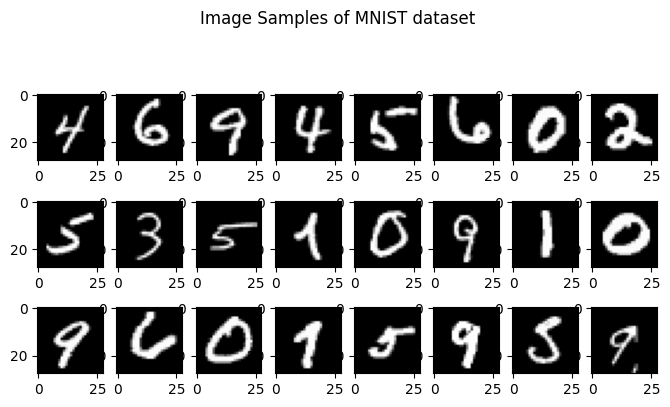

In [6]:
d.show_samples()

In [7]:
class Autoencoder:

    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train = x_train
        self.y_test = y_test
        self.y_train = y_train
        self.x_test = x_test
        self.IMG_DIM = (28,28,1)
        self.x = None

    def design_encoder(self):
        self.input = Input(shape=(28, 28, 1))
        self.x = Conv2D(filters = 16, kernel_size = (3, 3), activation='relu', padding='same')(self.input)
        self.x = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

        self.x = Conv2D(filters = 8, kernel_size = (3, 3), activation='relu', padding='same')(self.x)
        self.x = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

        self.x = Conv2D(filters = 8, kernel_size = (3, 3), activation='relu', padding='same')(self.x)
        self.encoded = MaxPooling2D(pool_size = (2, 2), padding='same')(self.x)

    def design_decoder(self):
        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.encoded)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(16, (3, 3), activation='relu')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)
        self.decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(self.x)

    def compile_model(self):
        self.model = keras.models.Model(self.input, self.decoded)
        self.model.compile(optimizer='adadelta', loss='binary_crossentropy')

    def fit_model(self):
        self.model.fit(self.x_train, self.x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(self.x_test, self.x_test)
        )


In [10]:
# This cell was redundant as 'a' is defined and trained in the cells below.

In [11]:
a = Autoencoder(d.x_train, d.y_train, d.x_test, d.y_test)

In [12]:
a.design_encoder()

In [13]:
a.design_decoder()

In [14]:
a.compile_model()

In [17]:
a.fit_model()

Epoch 1/10
254/469 ━━━━━━━━━━━━━━━━━━━━ 28s 131ms/step - loss: -515.0847

KeyboardInterrupt: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


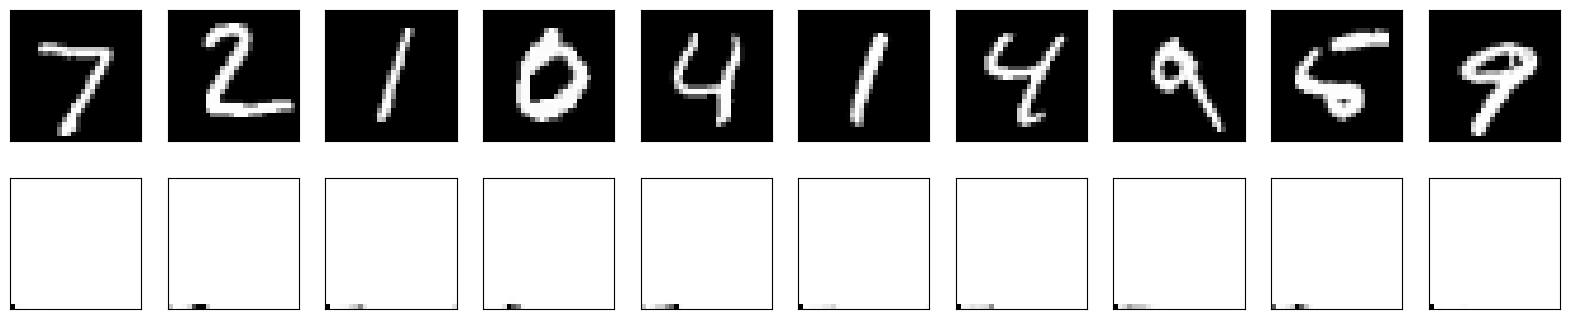

In [16]:
decoded_imgs = a.model.predict(a.x_test)

n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(a.x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()